# ✈️ British Airways Data Science Job Simulation

## Task 2: Predicting Customer Buying Behaviour

### Project Overview

This notebook presents the solution to Task 2 of the British Airways Data Science Job Simulation on Forage.

The objective of this project is to develop a machine learning model that predicts whether a customer will complete a holiday booking based on historical booking behaviour. By identifying the factors that influence booking completion, British Airways can improve customer targeting, optimize marketing campaigns, and increase booking conversion rates.

### Objectives

This project aims to:

- Explore and understand customer booking data through exploratory data analysis (EDA).
- Clean and preprocess the dataset for machine learning.
- Engineer relevant features for predictive modelling.
- Train and evaluate a Random Forest classifier.
- Identify the key factors influencing booking completion.
- Provide actionable business recommendations based on the model's findings.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Jupyter Notebook

---

**Author:** Lucy Rabera Ogendi  
**Project:** British Airways Data Science Job Simulation (Forage)

In [60]:
## Import Libraries

import pandas as pd

In [61]:
## load Dataset
df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")
df.head(10)

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0
5,1,Internet,RoundTrip,3,48,20,Thu,AKLDEL,New Zealand,1,0,1,5.52,0
6,3,Internet,RoundTrip,201,33,6,Thu,AKLDEL,New Zealand,1,0,1,5.52,0
7,2,Internet,RoundTrip,238,19,14,Mon,AKLDEL,India,1,0,1,5.52,0
8,1,Internet,RoundTrip,80,22,4,Mon,AKLDEL,New Zealand,0,0,1,5.52,0
9,1,Mobile,RoundTrip,378,30,12,Sun,AKLDEL,India,0,0,0,5.52,0


The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

## Exploratory Data Analysis

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [63]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [64]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)

In [65]:
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5])

In [66]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.

In [67]:
#check class balance for the target variable
df['booking_complete'].value_counts()

booking_complete
0    42522
1     7478
Name: count, dtype: int64

In [68]:
df['booking_complete'].value_counts(normalize=True) * 100

booking_complete
0    85.044
1    14.956
Name: proportion, dtype: float64

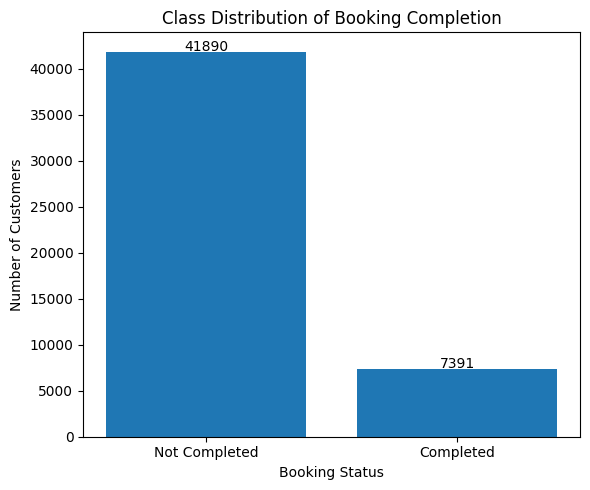

In [111]:
import matplotlib.pyplot as plt

# Count target classes
class_counts = df['booking_complete'].value_counts().sort_index()

# Plot
plt.figure(figsize=(6,5))

plt.bar(
    ['Not Completed', 'Completed'],
    class_counts.values
)

plt.title('Class Distribution of Booking Completion')
plt.xlabel('Booking Status')
plt.ylabel('Number of Customers')

# Add labels on bars
for i, value in enumerate(class_counts.values):
    plt.text(i, value + 100, str(value), ha='center')

plt.tight_layout()
plt.show()

In [69]:
# Check duplicate rows
duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")
print(f"Percentage of duplicate rows: {(duplicates/len(df))*100:.2f}%")

Number of duplicate rows: 719
Percentage of duplicate rows: 1.44%


In [70]:
df[df.duplicated()]

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
196,5,Internet,RoundTrip,206,17,13,7,AKLKUL,Malaysia,1,0,0,8.83,0
316,5,Internet,RoundTrip,206,17,13,7,AKLKUL,Malaysia,1,0,0,8.83,0
384,5,Internet,RoundTrip,206,17,13,7,AKLKUL,Malaysia,1,0,0,8.83,0
456,1,Internet,RoundTrip,30,85,15,5,AKLKUL,Malaysia,1,0,0,8.83,1
513,3,Internet,RoundTrip,109,20,4,2,AKLKUL,Singapore,1,0,1,8.83,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49852,2,Internet,RoundTrip,204,6,14,2,PENTPE,Malaysia,1,0,0,4.67,0
49902,1,Mobile,RoundTrip,106,6,11,5,PENTPE,Taiwan,1,0,0,4.67,0
49934,1,Internet,RoundTrip,2,6,3,4,PENTPE,Malaysia,0,0,1,4.67,0
49944,1,Internet,RoundTrip,2,6,3,4,PENTPE,Malaysia,0,0,1,4.67,0


In [71]:
df = df.drop_duplicates()

In [72]:
df.isnull().sum()

num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

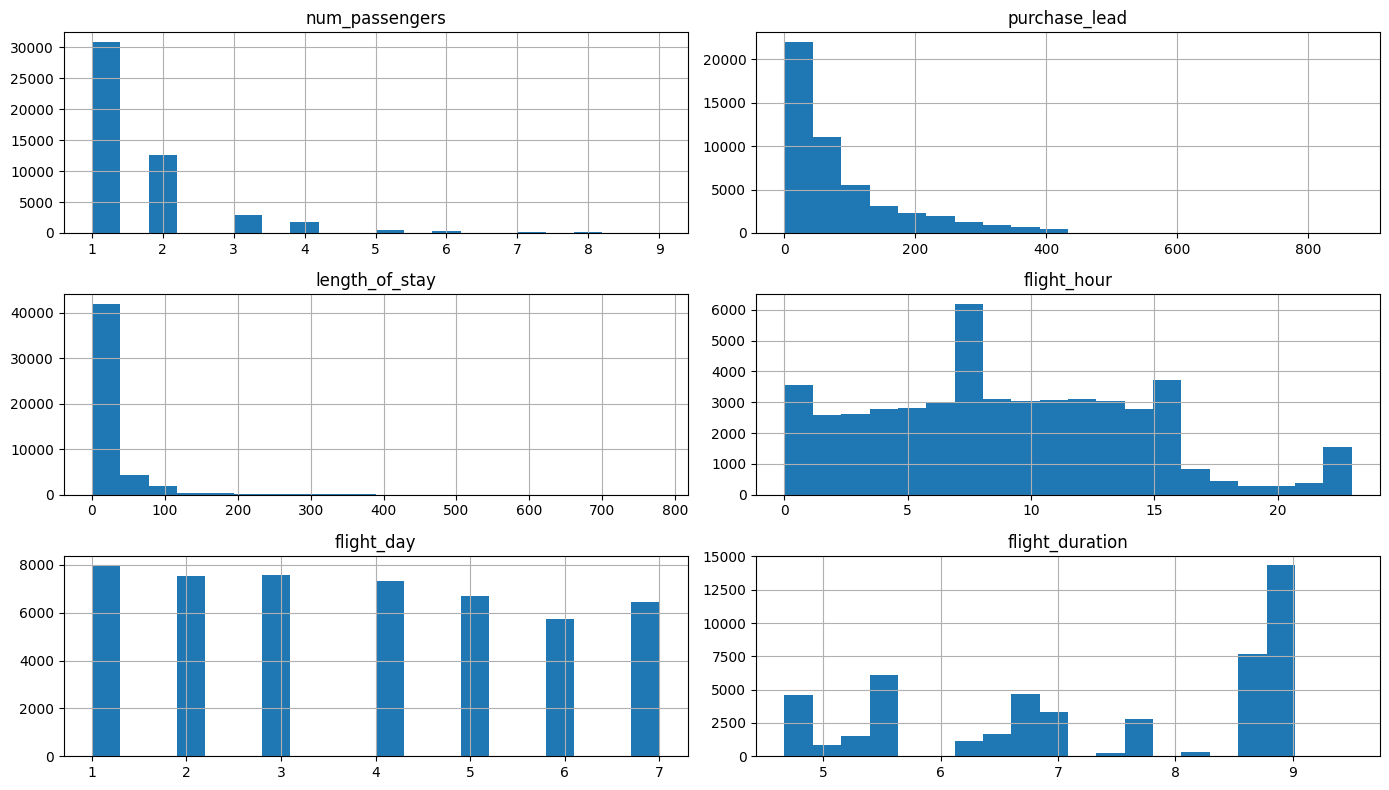

In [73]:
#distribution of numerical values
import matplotlib.pyplot as plt

numeric_cols = [
    'num_passengers',
    'purchase_lead',
    'length_of_stay',
    'flight_hour',
    'flight_day',
    'flight_duration'
]

df[numeric_cols].hist(figsize=(14,8), bins=20)

plt.tight_layout()
plt.show()

In [74]:
#distribution of binary columns.
binary_cols = [
    'wants_extra_baggage',
    'wants_preferred_seat',
    'wants_in_flight_meals'
]

for col in binary_cols:
    print(f"\n{col}")
    print(df[col].value_counts())
    print(df[col].value_counts(normalize=True).mul(100).round(2))




wants_extra_baggage
wants_extra_baggage
1    32931
0    16350
Name: count, dtype: int64
wants_extra_baggage
1    66.82
0    33.18
Name: proportion, dtype: float64

wants_preferred_seat
wants_preferred_seat
0    34712
1    14569
Name: count, dtype: int64
wants_preferred_seat
0    70.44
1    29.56
Name: proportion, dtype: float64

wants_in_flight_meals
wants_in_flight_meals
0    28256
1    21025
Name: count, dtype: int64
wants_in_flight_meals
0    57.34
1    42.66
Name: proportion, dtype: float64


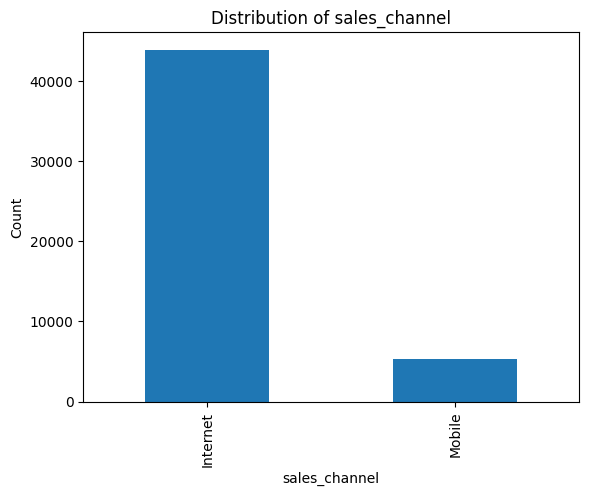

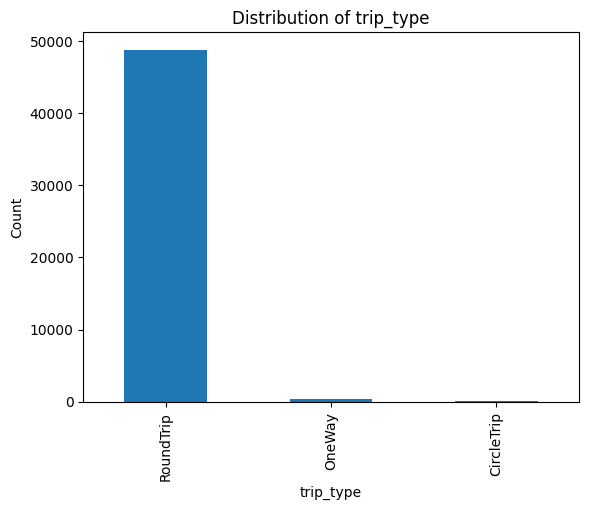

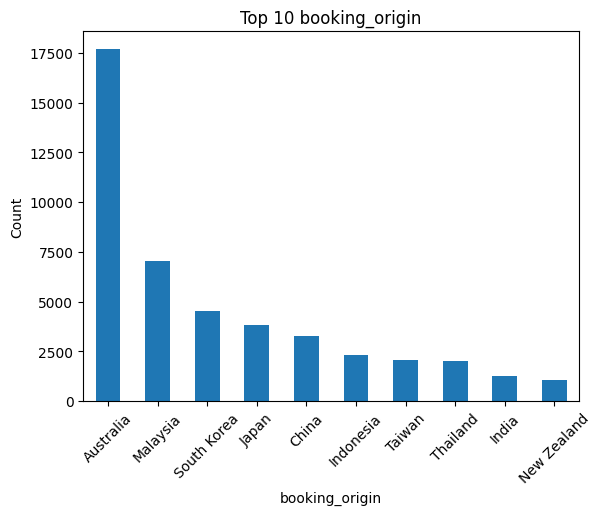

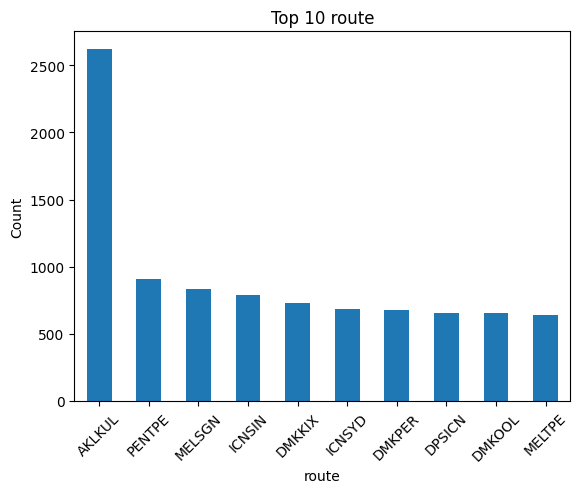

In [75]:
import matplotlib.pyplot as plt

# Categorical columns with few categories
few_categories = [
    'sales_channel',
    'trip_type'
]

# Categorical columns with many categories
many_categories = [
    'booking_origin',
    'route'
]

# Plot columns with few categories
for col in few_categories:
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

# Plot only the top 10 categories for high-cardinality columns
for col in many_categories:
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f'Top 10 {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

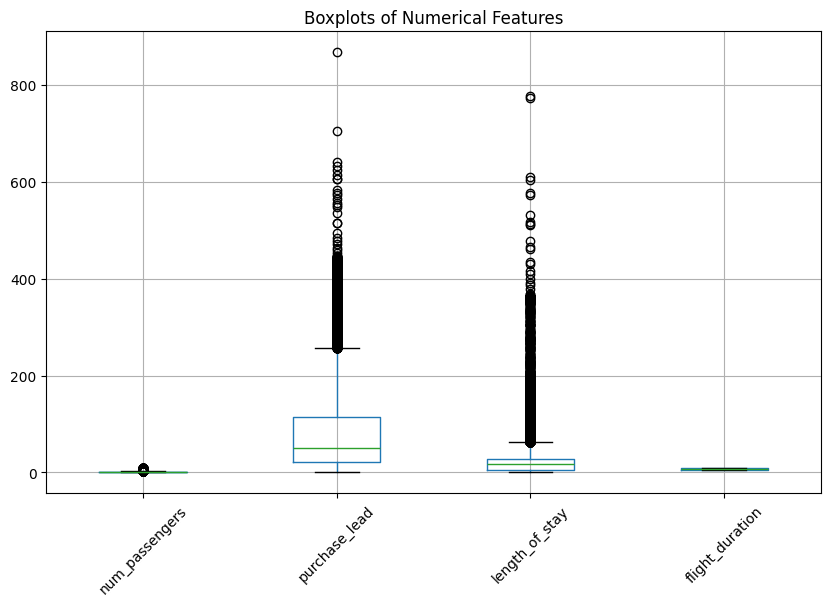

In [76]:
#outliers
import matplotlib.pyplot as plt

outlier_cols = [
    'num_passengers',
    'purchase_lead',
    'length_of_stay',
    'flight_duration'
]

plt.figure(figsize=(10,6))
df[outlier_cols].boxplot()

plt.title('Boxplots of Numerical Features')
plt.xticks(rotation=45)
plt.show()

In [77]:
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

num_passengers: 2851 outliers
purchase_lead: 3391 outliers
length_of_stay: 3748 outliers
flight_duration: 0 outliers


In [78]:
#numeric features vs target variable
df.groupby('booking_complete')[numeric_cols].mean()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,flight_duration
booking_complete,,,,,,
0,1.579900,85.563762,23.651969,9.055431,3.819527,7.346932
1,1.648491,79.959681,19.664727,9.157083,3.780138,6.900475


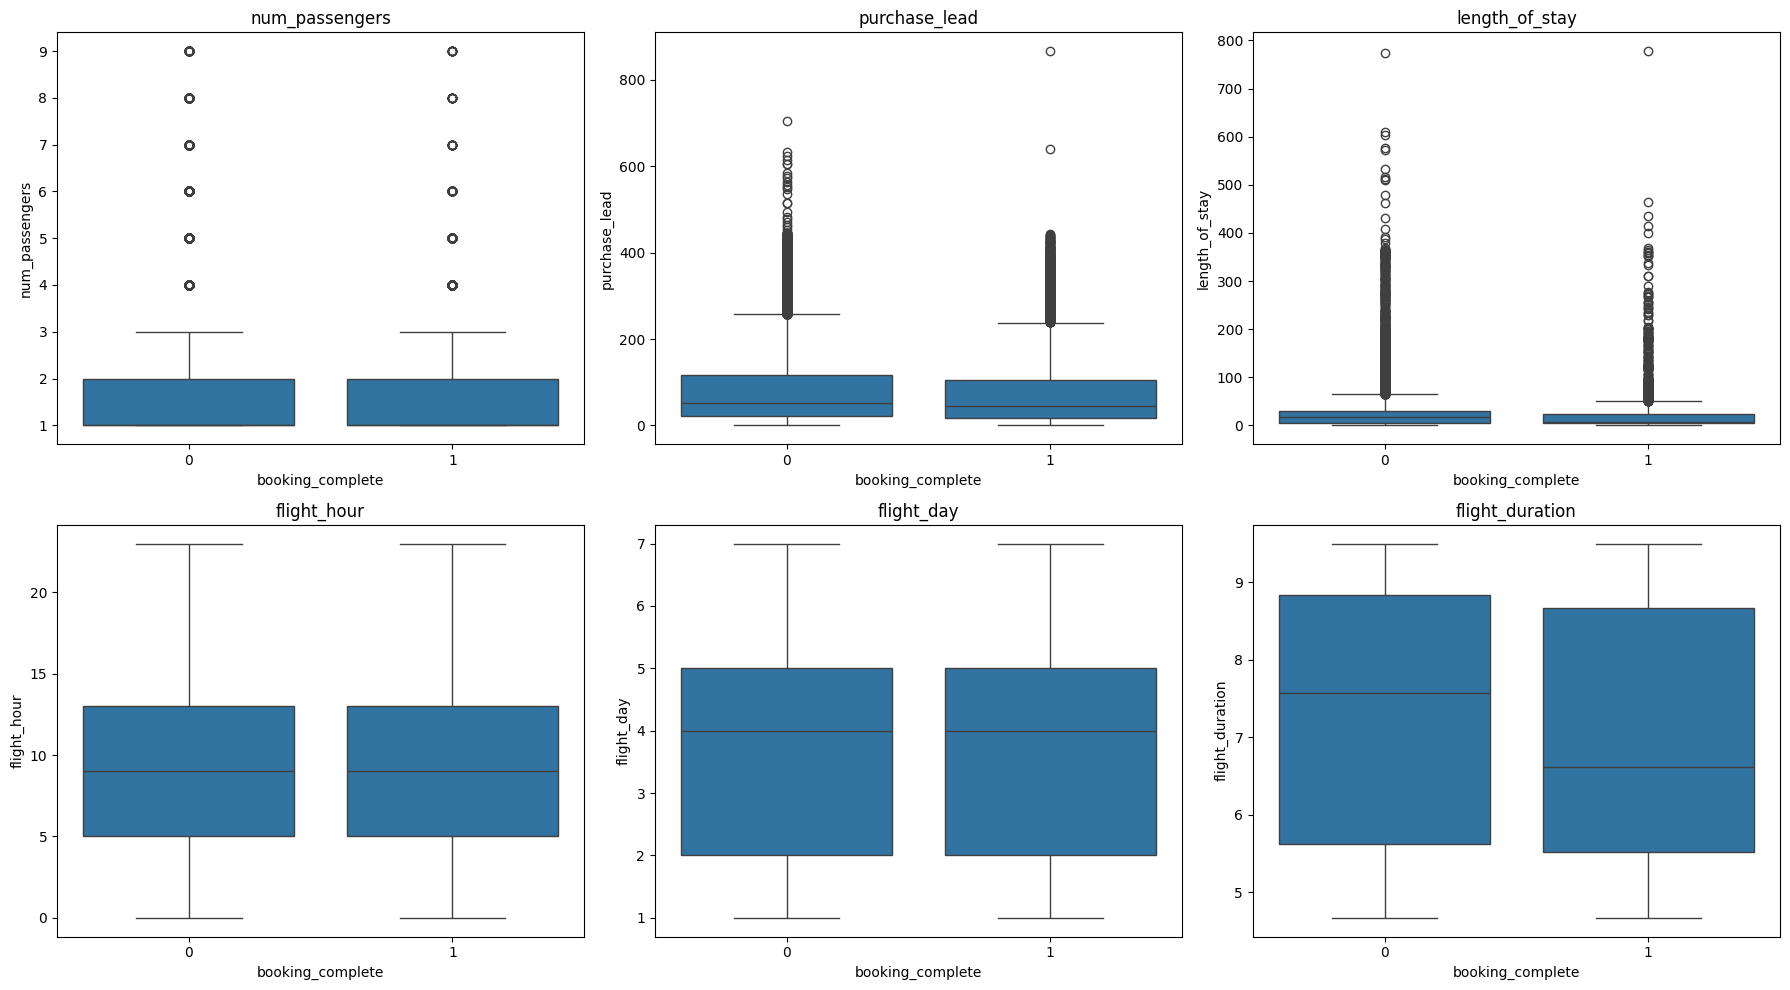

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    'num_passengers',
    'purchase_lead',
    'length_of_stay',
    'flight_hour',
    'flight_day',
    'flight_duration'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(
        x='booking_complete',
        y=col,
        data=df,
        ax=ax
    )
    ax.set_title(f'{col}')

plt.tight_layout()
plt.show()

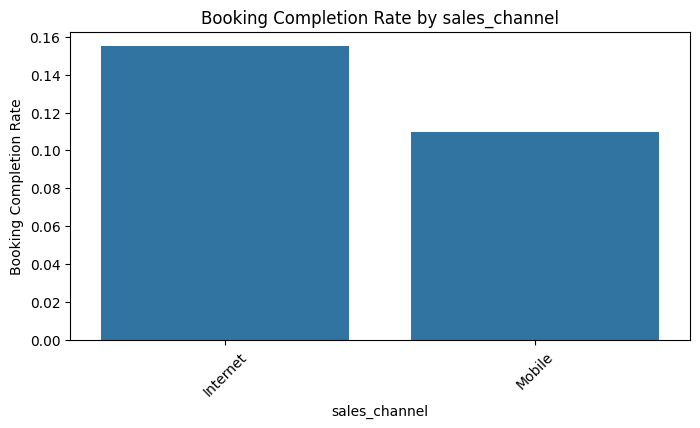

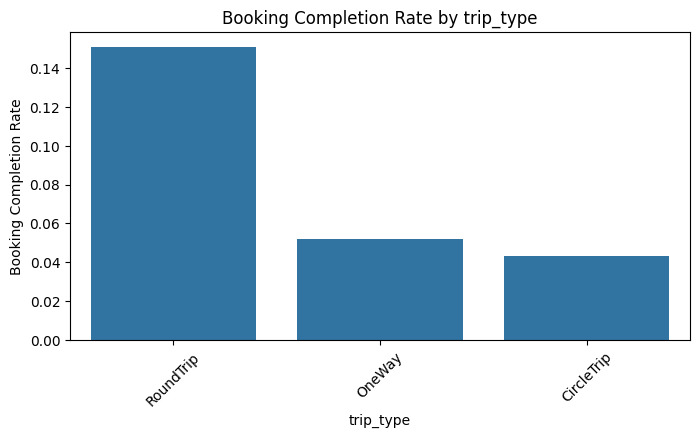

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

cats_col = ['sales_channel',
            'trip_type'
           ]
    

for col in cats_col:

    plt.figure(figsize=(8,4))

    booking_rate = (
        df.groupby(col)['booking_complete']
        .mean()
        .sort_values(ascending=False)
    )

    sns.barplot(
        x=booking_rate.index,
        y=booking_rate.values
    )

    plt.title(f'Booking Completion Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Booking Completion Rate')

    plt.xticks(rotation=45)
    plt.show()

### Observations

- Customers who booked through the **Internet** had a higher booking completion rate than those who booked through the **Mobile** sales channel.

- Customers booking **RoundTrip** flights had the highest booking completion rate compared to **OneWay** and **CircleTrip** bookings.

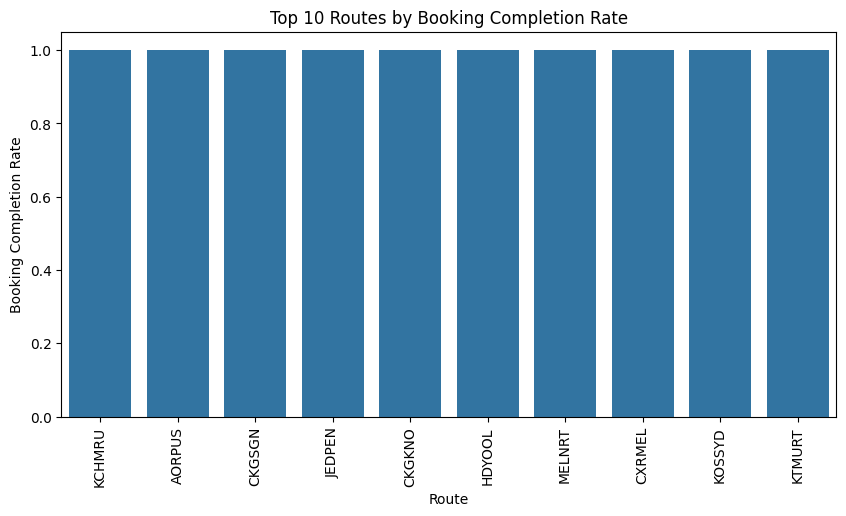

In [81]:
route_rate = (
    df.groupby('route')['booking_complete']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=route_rate.index, y=route_rate.values)

plt.xticks(rotation=90)
plt.title("Top 10 Routes by Booking Completion Rate")
plt.ylabel("Booking Completion Rate")
plt.xlabel("Route")

plt.show()

### Observation

- The top 10 routes exhibited consistently high booking completion rates, with only small differences observed between them.

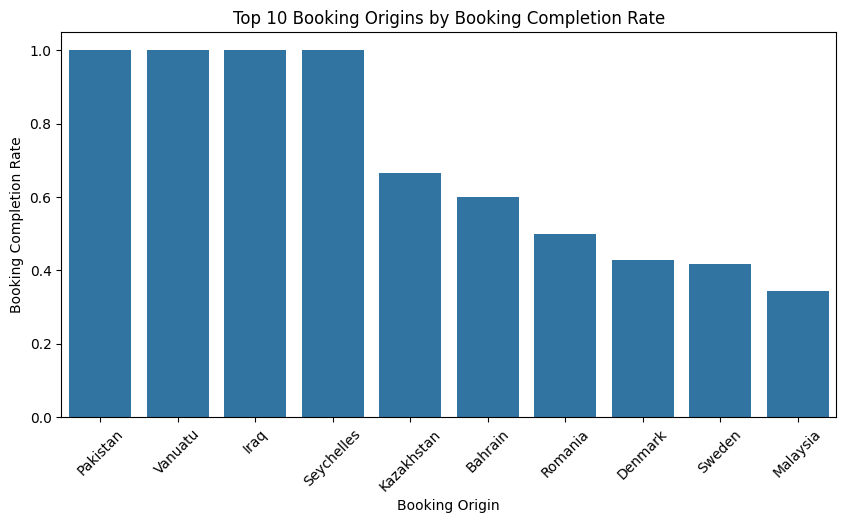

In [82]:
origin_rate = (
    df.groupby('booking_origin')['booking_complete']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=origin_rate.index, y=origin_rate.values)

plt.xticks(rotation=45)
plt.title("Top 10 Booking Origins by Booking Completion Rate")
plt.ylabel("Booking Completion Rate")
plt.xlabel("Booking Origin")

plt.show()

### Observation
- Among the top ten booking origins, customers who booked from **Seychelles**,**Iraq**, **Pakistan** and **Vanuatu** had the highest completion rates.

In [83]:
#boolean features vs target 
bool_cols = [
    'wants_extra_baggage',
    'wants_preferred_seat',
    'wants_in_flight_meals'
]


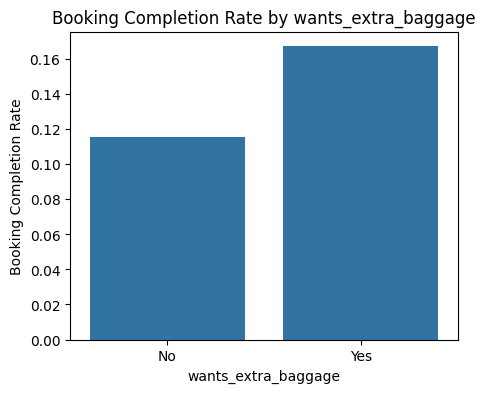

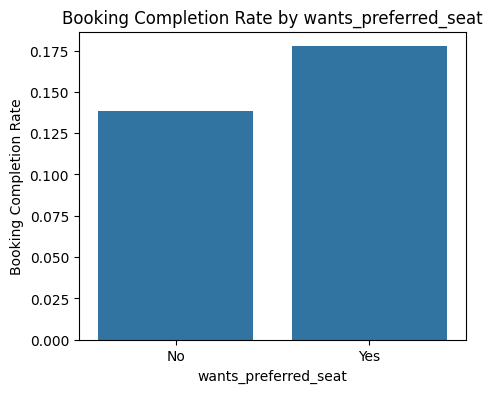

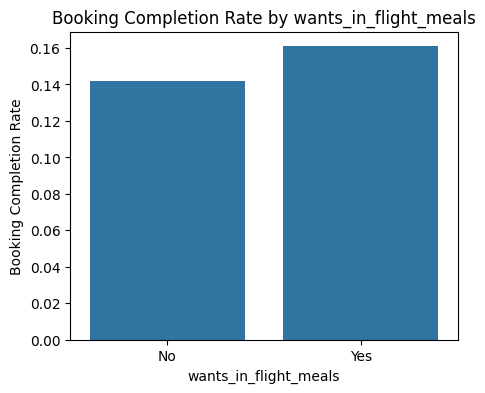

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in bool_cols:

    booking_rate = (
        df.groupby(col)['booking_complete']
          .mean()
          .reset_index()
    )

    plt.figure(figsize=(5,4))

    sns.barplot(
        data=booking_rate,
        x=col,
        y='booking_complete'
    )

    plt.title(f'Booking Completion Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Booking Completion Rate')

    plt.xticks([0,1], ['No','Yes'])

    plt.show()

### Observations

- Customers who requested **extra baggage** had a higher booking completion rate than those who did not request extra baggage.

- Customers who requested **preferred seats** had a higher booking completion rate than those who did not request preferred seats.

- Customers who requested **in-flight meals** had a slightly higher booking completion rate than those who did not request in-flight meals..

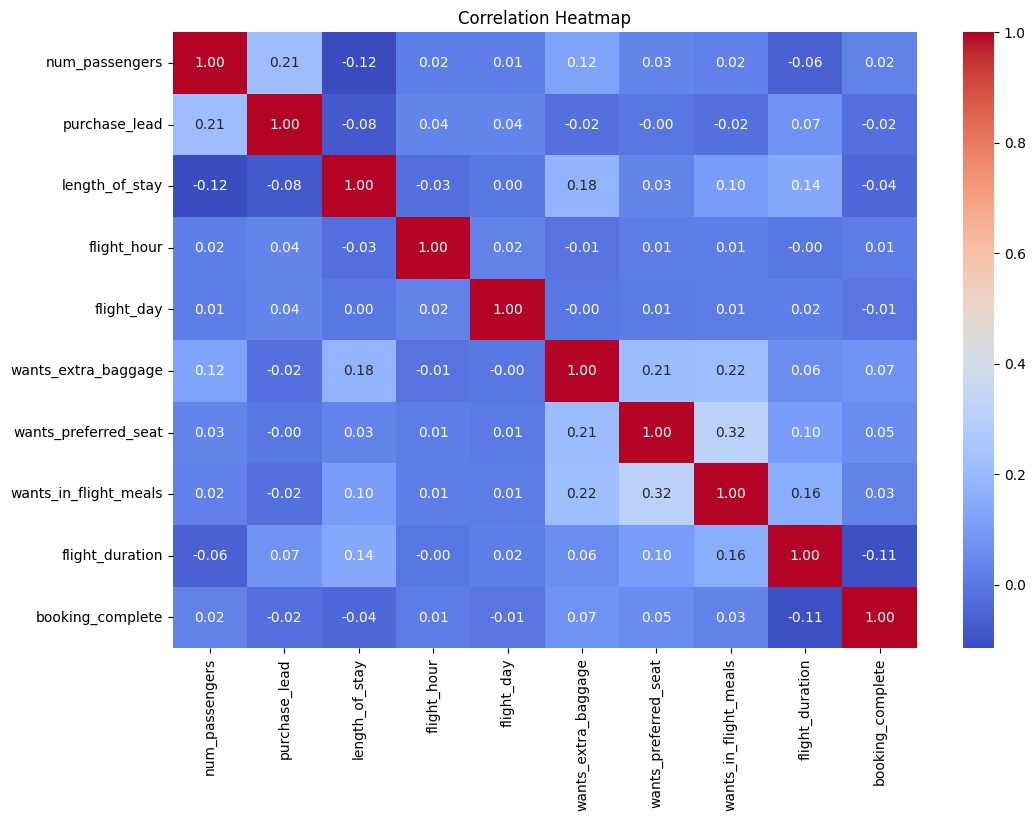

In [85]:
#Correlation heatmap for feature vs feature relationship.
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

### Observations

- Most features exhibited **very weak correlations** with one another, with correlation coefficients generally ranging from **0.00 to 0.07**. This suggests that there is little linear relationship between most features and a low likelihood of multicollinearity.

- The service-related features (`wants_extra_baggage`, `wants_preferred_seat`, and `wants_in_flight_meals`) also showed **very weak positive correlations** with `booking_complete`, indicating only a slight linear association with booking completion.

- A small number of feature pairs showed **weak positive correlations** (around **0.10–0.32**), but none reached the level of a moderate or strong correlation.

## Data Preprocessing

Before training the machine learning model, the dataset was preprocessed to ensure it was clean, consistent, and suitable for analysis. Raw data often contains duplicate records, categorical variables, and other inconsistencies that can negatively affect model performance if left unaddressed.

The preprocessing stage involved preparing the data by removing duplicate observations, encoding categorical variables into numerical representations, selecting relevant features, and separating the target variable from the predictor variables. Finally, the dataset was split into training and testing sets to enable an unbiased evaluation of the model's performance on unseen data.

These preprocessing steps provide a solid foundation for building a reliable predictive model and help improve the accuracy and generalizability of the results.

In [86]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df_original = pd.read_csv("customer_booking.csv", encoding="latin1")

In [87]:
#Data Preprocessing
# Remove duplicates
df_original = df_original.drop_duplicates().copy()

# Frequency encode route
route_freq = df_original['route'].value_counts()
df_original['route'] = df_original['route'].map(route_freq)

# Label encode sales_channel
le = LabelEncoder()
df_original['sales_channel'] = le.fit_transform(df_original['sales_channel'])

# One-hot encode trip_type, flight_day and booking_origin
df_original = pd.get_dummies(
    df_original,
    columns=['trip_type', 'flight_day', 'booking_origin'],
    drop_first=True,
    dtype=int
)


In [88]:
df_original

,num_passengers,sales_channel,purchase_lead,length_of_stay,flight_hour,route,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,...,booking_origin_Timor-Leste,booking_origin_Tonga,booking_origin_Tunisia,booking_origin_Turkey,booking_origin_Ukraine,booking_origin_United Arab Emirates,booking_origin_United Kingdom,booking_origin_United States,booking_origin_Vanuatu,booking_origin_Vietnam
0,2,0,262,19,7,20,1,0,0,5.52,...,0,0,0,0,0,0,0,0,0,0
1,1,0,112,20,3,20,0,0,0,5.52,...,0,0,0,0,0,0,0,0,0,0
2,2,0,243,22,17,20,1,1,0,5.52,...,0,0,0,0,0,0,0,0,0,0
3,1,0,96,31,4,20,0,0,1,5.52,...,0,0,0,0,0,0,0,0,0,0
4,2,0,68,22,15,20,1,0,1,5.52,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2,0,27,6,9,218,1,0,1,5.62,...,0,0,0,0,0,0,0,0,0,0
49996,1,0,111,6,4,218,0,0,0,5.62,...,0,0,0,0,0,0,0,0,0,0
49997,1,0,24,6,22,218,0,0,1,5.62,...,0,0,0,0,0,0,0,0,0,0
49998,1,0,15,6,11,218,1,0,1,5.62,...,0,0,0,0,0,0,0,0,0,0


In [89]:
df_original.columns.tolist()

['num_passengers',
 'sales_channel',
 'purchase_lead',
 'length_of_stay',
 'flight_hour',
 'route',
 'wants_extra_baggage',
 'wants_preferred_seat',
 'wants_in_flight_meals',
 'flight_duration',
 'booking_complete',
 'trip_type_OneWay',
 'trip_type_RoundTrip',
 'flight_day_Mon',
 'flight_day_Sat',
 'flight_day_Sun',
 'flight_day_Thu',
 'flight_day_Tue',
 'flight_day_Wed',
 'booking_origin_Afghanistan',
 'booking_origin_Algeria',
 'booking_origin_Argentina',
 'booking_origin_Australia',
 'booking_origin_Austria',
 'booking_origin_Bahrain',
 'booking_origin_Bangladesh',
 'booking_origin_Belarus',
 'booking_origin_Belgium',
 'booking_origin_Bhutan',
 'booking_origin_Brazil',
 'booking_origin_Brunei',
 'booking_origin_Bulgaria',
 'booking_origin_Cambodia',
 'booking_origin_Canada',
 'booking_origin_Chile',
 'booking_origin_China',
 'booking_origin_Colombia',
 'booking_origin_Croatia',
 'booking_origin_Cyprus',
 'booking_origin_Czech Republic',
 'booking_origin_Czechia',
 'booking_origin_De

In [90]:
#separate features and target
X = df_original.drop('booking_complete', axis=1)
y = df_original['booking_complete']

In [91]:
#traintest split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Model Building

With the data cleaned and preprocessed, the next step is to develop a machine learning model capable of predicting whether a customer will complete a booking. The objective is to learn patterns from historical booking data and use those patterns to make accurate predictions on new, unseen customer records.

For this project, a **Random Forest Classifier** was selected due to its ability to handle both numerical and categorical features, capture complex relationships within the data, and reduce the risk of overfitting by combining predictions from multiple decision trees. The model was trained using the training dataset and later evaluated on a separate testing dataset to assess its predictive performance.

Building this predictive model enables British Airways to better understand customer booking behaviour and provides a foundation for developing data-driven marketing and customer engagement strategies.

In [92]:
#build model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

In [93]:
#train model
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [94]:
#predictions
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(9857,))

## Model Evaluation

After training the Random Forest classifier, the next step is to evaluate how well the model performs on unseen data. Model evaluation helps determine whether the model can accurately distinguish between customers who complete a booking and those who do not.

To provide a comprehensive assessment, several evaluation metrics are used, including accuracy, precision, recall, F1-score, and the Receiver Operating Characteristic - Area Under the Curve (ROC-AUC). In addition, a confusion matrix is used to visualize the model's classification performance by comparing predicted outcomes with the actual outcomes.

Together, these evaluation techniques provide a balanced understanding of the model's predictive performance, highlight its strengths and limitations, and help determine whether it is suitable for supporting data-driven business decisions at British Airways.

In [95]:
#evaluate the model with classification_report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.98      0.92      8379
           1       0.47      0.09      0.15      1478

    accuracy                           0.85      9857
   macro avg       0.66      0.54      0.53      9857
weighted avg       0.80      0.85      0.80      9857



In [96]:
#evaluate the model with confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[8232  147]
 [1348  130]]


## Hyperparameter Tuning Using GridSearchCV

While the initial Random Forest model provides a strong baseline, its performance can often be improved by optimizing its hyperparameters. Hyperparameters are settings that control how the model is trained and can significantly influence its ability to generalize to new data.

In this project, **GridSearchCV** was used to systematically evaluate different combinations of hyperparameters through cross-validation. This approach identifies the set of parameters that yields the best predictive performance while reducing the risk of overfitting.

The hyperparameters explored include:

- **n_estimators:** Number of decision trees in the forest.
- **max_depth:** Maximum depth of each decision tree.
- **min_samples_split:** Minimum number of samples required to split an internal node.
- **min_samples_leaf:** Minimum number of samples required at a leaf node.
- **max_features:** Number of features considered when searching for the best split.

The model was evaluated using **ROC-AUC** as the scoring metric, as it provides a robust measure of the model's ability to distinguish between customers who complete a booking and those who do not. The best-performing parameter combination was then used to train the final Random Forest model.

In [97]:
param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [10, 12],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

In [98]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

In [99]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 12], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramete

### Best Model Parameters

GridSearchCV identified the optimal combination of hyperparameters that maximized the model's ROC-AUC score. The optimized Random Forest model was then retrained using these parameters and evaluated on the test dataset to assess its performance and generalizability.

In [100]:
#best model
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}


In [101]:
print("Best Cross_Validation ROC_AUC:", grid_search.best_score_)


Best Cross_Validation ROC_AUC: 0.7696712745327632


In [102]:
best_rf = grid_search.best_estimator_
print(best_rf)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, random_state=42)


In [103]:
y_preds = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]


In [104]:
#final model evaluation
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print(classification_report(y_test, y_preds))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.93      0.72      0.81      8379
           1       0.30      0.68      0.42      1478

    accuracy                           0.71      9857
   macro avg       0.61      0.70      0.61      9857
weighted avg       0.83      0.71      0.75      9857

ROC-AUC: 0.7636435957475364
[[6004 2375]
 [ 469 1009]]


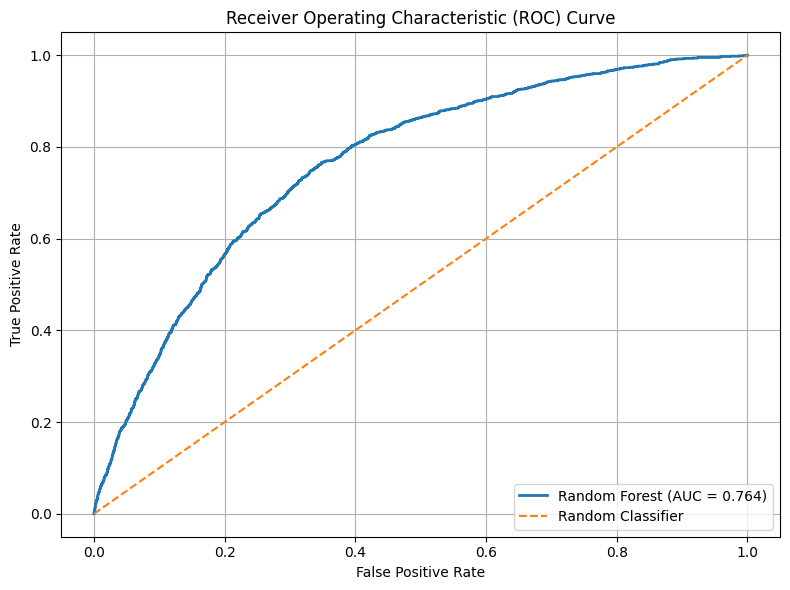

In [106]:
#ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities
y_prob = best_rf.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC
roc_auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'Random Forest (AUC = {roc_auc:.3f})',
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')

plt.legend(loc='lower right')

plt.grid(True)

plt.tight_layout()
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## Feature Importance Analysis

Understanding which variables have the greatest influence on booking completion is just as important as building an accurate predictive model. Feature importance analysis helps identify the factors that contribute most to the model's predictions, providing valuable insights into customer behaviour.

In this project, feature importance is extracted from the trained Random Forest classifier. Each feature is assigned an importance score based on its contribution to reducing prediction errors across the decision trees in the model. Features with higher scores have a greater impact on predicting whether a customer completes a booking.

These insights can help British Airways better understand the drivers of customer purchasing behaviour, enabling more informed decisions in areas such as targeted marketing, customer segmentation, and service optimization.


In [ ]:
# feature importance
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

In [ ]:
# feature Importance Chart
import matplotlib.pyplot as plt

# Extract feature importances
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Plot
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.gca().invert_yaxis()

plt.title('Feature Importance - Random Forest Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()